# F500 Problem Set 1

## Exercice 1

First obtain daily price data on a stock index and two individual stocks from a market of your choice. The method for assignment is given below. The calculations can be performed in Excel and/or Eviews, but also in other software packages, as you prefer.

### 1.a)

Compute the sample statistics of the stock return (computed from the daily closing price) series, i.e., the mean, standard deviation, skewness and kurtosis. You may ignore dividends and just focus on capital gain.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
import seaborn as sns


The two stocks I am analysing are from the SMI. I will analyse UBS stocks and Lonza stocks.
I am downloading 20 years of daily data.

The columns of the dataset are:

- open: price at which the stock first traded when the market opened that day (reflects overnight information)
- high: highest transaction price reached during that trading day
- low: lowest transaction price during that trading day
- close: final traded price at market close
- adj close: closing price adjusted for dividends, stock splits and corporate actions (reflects the true capital gain including reinvested dividends)
- volume: number of shares during the day



In [10]:
tickers = ["UBSG.SW", "LONN.SW", "^SSMI"]

df = yf.download(
    tickers,
    start="2005-01-01",
    end="2025-01-01",
    interval="1d",
    auto_adjust=False
)


[*********************100%***********************]  3 of 3 completed


In [11]:
# Compute daily simple returns from closing prices (ignoring dividends)
close = df['Close']
returns = close.pct_change().dropna()

# pct_change() is build in pandas and computes the percentage change between consecutive rows.
# r_t = (P_t - P_{t-1}) / P_{t-1}

# skew() is a measure of asymmetry
# kurtosis() measures howw heavy are the tails compared to a normal distribution.

# Sample statistics
stats = pd.DataFrame({
    "Mean": returns.mean(),
    "Std Dev": returns.std(),
    "Skewness": returns.skew(),
    "Kurtosis (Excess)": returns.kurtosis()
})

print(stats)


             Mean   Std Dev  Skewness  Kurtosis (Excess)
Ticker                                                  
LONN.SW  0.000604  0.018527 -1.148737          15.564201
UBSG.SW  0.000149  0.022844  0.582286          15.954942
^SSMI    0.000192  0.010506 -0.224584           9.940244


We are studying returns, not prices. Raw prices are not directly comparable across stocks. Percentages normalize it and gives a rate of return that is comparable and unit free.

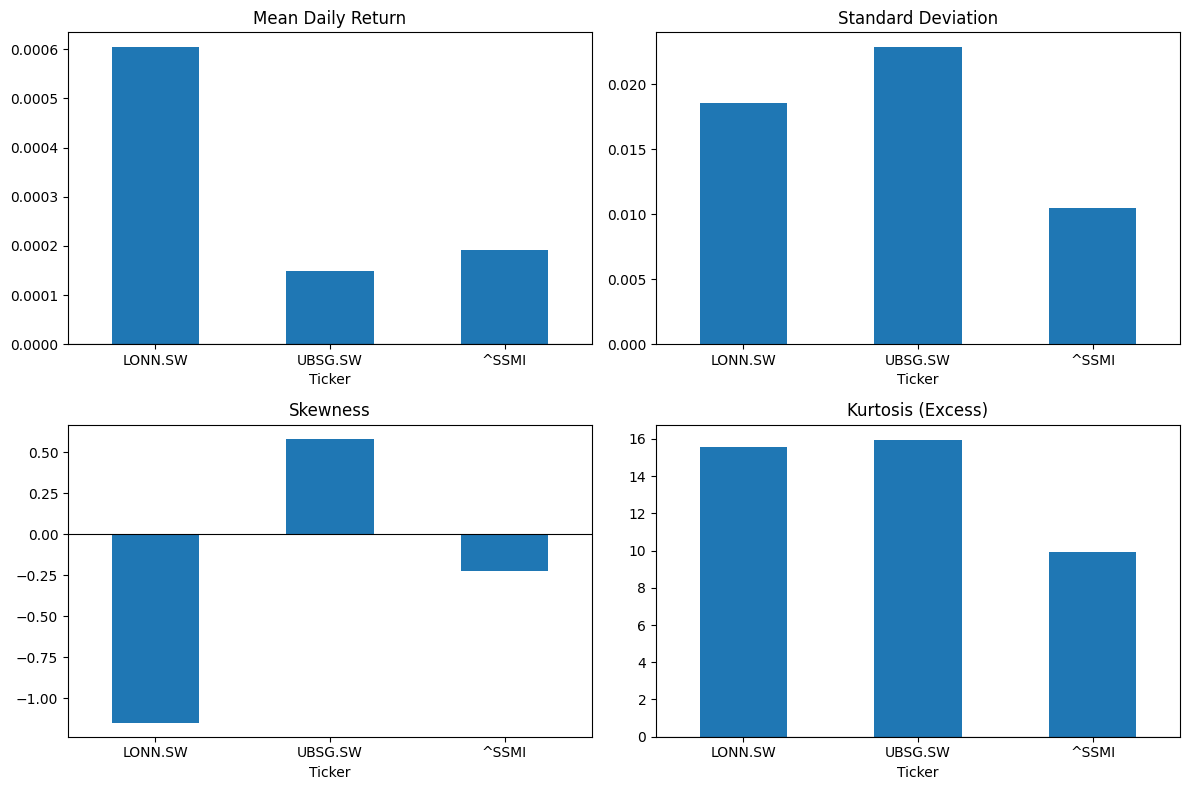

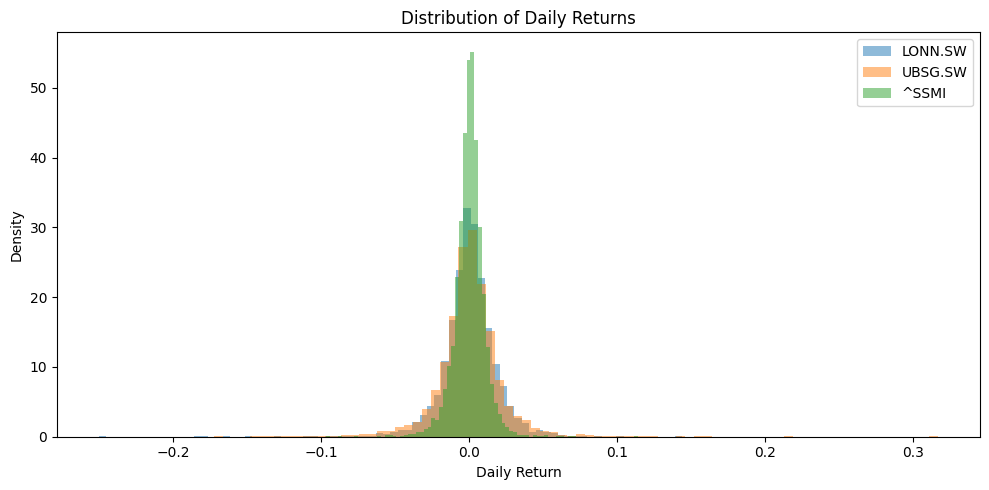

In [12]:
# Bar charts comparing summary statistics across the three series
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

stats['Mean'].plot(kind='bar', ax=axes[0, 0], title='Mean Daily Return')
axes[0, 0].axhline(0, color='k', linewidth=0.8)

stats['Std Dev'].plot(kind='bar', ax=axes[0, 1], title='Standard Deviation')

stats['Skewness'].plot(kind='bar', ax=axes[1, 0], title='Skewness')
axes[1, 0].axhline(0, color='k', linewidth=0.8)

stats['Kurtosis (Excess)'].plot(kind='bar', ax=axes[1, 1], title='Kurtosis (Excess)')
axes[1, 1].axhline(0, color='k', linewidth=0.8)

for ax in axes.flat:
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Overlaid histograms to compare return distributions
fig, ax = plt.subplots(figsize=(10, 5))
for col in returns.columns:
    ax.hist(returns[col], bins=80, alpha=0.5, label=col, density=True)
ax.set_xlabel('Daily Return')
ax.set_ylabel('Density')
ax.set_title('Distribution of Daily Returns')
ax.legend()
plt.tight_layout()
plt.show()



Lonza has the highest mean daily return, but also high volatility.
UBS has moderate return but with a higher volatility to Lonza.
SMI has the lowest return but also a much lowest volatility.

The skewness is negative for most stocks, which show that they usually have more frequent large negative returns than positive ones. UBS has a positive skewness which means it has more frequent small losses, but occasional large gains.

The fat tails indicate that extreme events occur much more frequently than a normal distribution would predict.

### 1b)
Compute the first 20 autocorrelation coefficients and test whether the series is linearly predictable or not.

In [13]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Compute first 20 autocorrelation coefficients
n_lags = 20

autocorr = pd.DataFrame(
    {col: [returns[col].autocorr(lag=i) for i in range(1, n_lags + 1)]
     for col in returns.columns},
    index=range(1, n_lags + 1)
)
autocorr.index.name = 'Lag'
print(autocorr)

# Each column is a stock, each row is a lag, each cell is the autocorrelation at that lag.
# The dictionnary comprehension is similar to that loop:
# result = {}
# for col in returns.columns:          # loop over each stock
#     values = []
#     for i in range(1, 21):            # loop over lags 1 to 20
#         ac = returns[col].autocorrelation(lag=i)  # corr(r_t, r_{t-i})
#         values.append(ac)
#     result[col] = values


      LONN.SW   UBSG.SW     ^SSMI
Lag                              
1    0.028283  0.075067  0.020277
2   -0.015577 -0.053440 -0.063034
3   -0.006156 -0.061464 -0.027157
4   -0.025325 -0.029631  0.036484
5   -0.024744 -0.003158 -0.055926
6    0.002259 -0.034834 -0.040939
7    0.025045 -0.018303  0.002122
8    0.004488  0.012441  0.005677
9   -0.008269  0.033603 -0.012845
10  -0.028112  0.005973  0.018960
11   0.018305 -0.033273 -0.000549
12   0.011454 -0.016310  0.001053
13  -0.005099 -0.025261 -0.024022
14  -0.018223 -0.026198 -0.024637
15  -0.002988 -0.006984 -0.017337
16   0.024306  0.057256  0.039285
17  -0.006663  0.020825 -0.011761
18  -0.005279 -0.013218 -0.015373
19  -0.006123 -0.002370  0.006530
20  -0.011222 -0.025757  0.006755


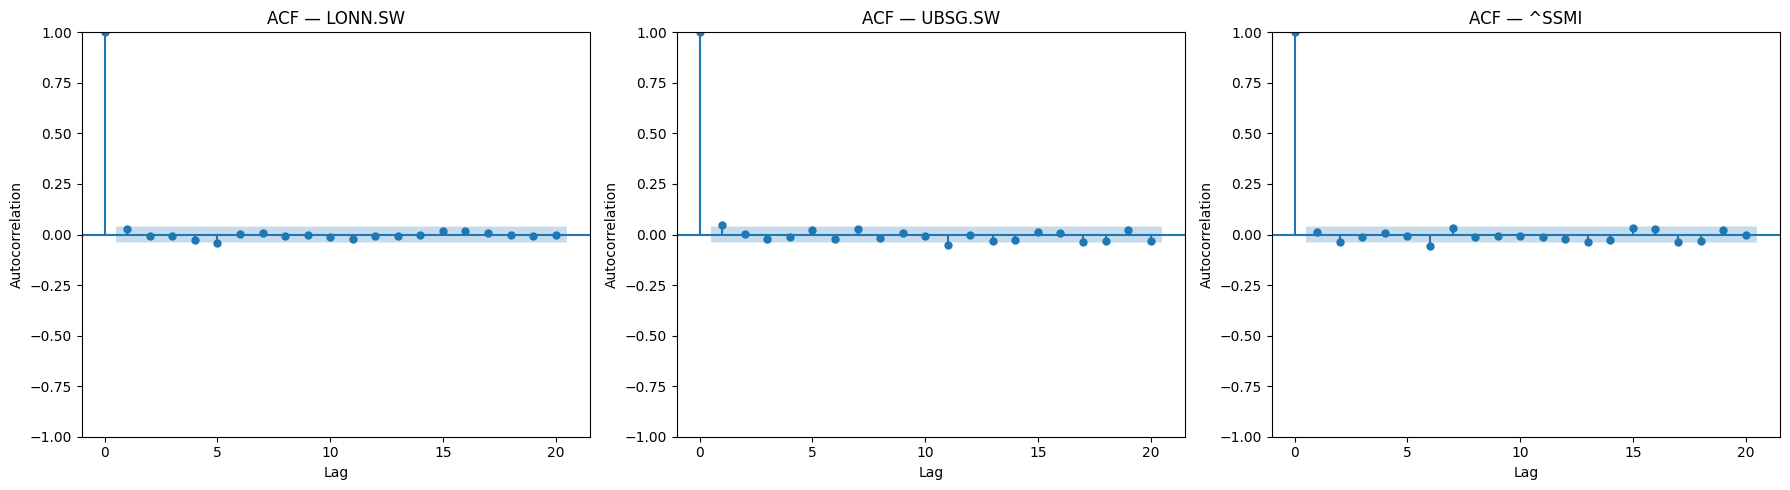

In [8]:
# Plot autocorrelation functions (ACF)
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, returns.columns):
    plot_acf(returns[col], lags=n_lags, ax=ax, title=f'ACF — {col}')
    ax.set_xlabel('Lag')
    ax.set_ylabel('Autocorrelation')
plt.tight_layout()
plt.show()


In [16]:
# Ljung-Box test for joint significance of autocorrelations
# H0: the first k autocorrelations are all zero (no linear predictability)
# H1: at least one autocorrelation is non-zero

# It test wheter a time seris has significant autocorrelation (wheter past returns help predict future returns).
# If a market is efficient, returns should be unpredictable, so all autocorrelations should be zero.

pd.set_option('display.max_rows', None)

col = "UBSG.SW"
lb_test = acorr_ljungbox(returns[col], lags=n_lags, return_df=True)
print(f"--- Ljung-Box Test: {col} ---")
print(lb_test)
p_val_20 = lb_test['lb_pvalue'].iloc[-1]
if p_val_20 < 0.05:
    print(f"=> Reject H0 at 5%: {col} returns show significant linear predictability.")
else:
    print(f"=> Cannot reject H0 at 5%: {col} returns show no significant linear predictability.")


--- Ljung-Box Test: UBSG.SW ---
       lb_stat     lb_pvalue
1    28.163709  1.114753e-07
2    42.436803  6.094882e-10
3    61.320129  3.070164e-13
4    65.709585  1.823749e-13
5    65.759432  7.797129e-13
6    71.824819  1.726124e-13
7    73.499666  2.890931e-13
8    74.273619  6.894153e-13
9    79.920707  1.675817e-13
10   80.099129  4.800795e-13
11   85.637111  1.187380e-13
12   86.967834  1.902397e-13
13   90.160581  1.302122e-13
14   93.595109  7.910313e-14
15   93.839244  1.896125e-13
16  110.250647  4.019096e-16
17  112.422001  4.219125e-16
18  113.296913  7.631159e-16
19  113.325044  1.937544e-15
20  116.648102  1.186613e-15
=> Reject H0 at 5%: UBSG.SW returns show significant linear predictability.


In [17]:
col = "LONN.SW"
lb_test = acorr_ljungbox(returns[col], lags=n_lags, return_df=True)
print(f"--- Ljung-Box Test: {col} ---")
print(lb_test)
p_val_20 = lb_test['lb_pvalue'].iloc[-1]
if p_val_20 < 0.05:
    print(f"=> Reject H0 at 5%: {col} returns show significant linear predictability.")
else:
    print(f"=> Cannot reject H0 at 5%: {col} returns show no significant linear predictability.")


--- Ljung-Box Test: LONN.SW ---
      lb_stat  lb_pvalue
1    3.997893   0.045557
2    5.210760   0.073875
3    5.400227   0.144729
4    8.607206   0.071703
5   11.668170   0.039629
6   11.693684   0.069162
7   14.830449   0.038235
8   14.930965   0.060502
9   15.272072   0.083729
10  19.209371   0.037683
11  20.879056   0.034646
12  21.532890   0.043101
13  21.662495   0.060817
14  23.318005   0.055288
15  23.362508   0.076741
16  26.307673   0.049850
17  26.528728   0.065351
18  26.667537   0.085446
19  26.854135   0.108097
20  27.481155   0.122262
=> Cannot reject H0 at 5%: LONN.SW returns show no significant linear predictability.


In [18]:
col = "^SSMI"
lb_test = acorr_ljungbox(returns[col], lags=n_lags, return_df=True)
print(f"--- Ljung-Box Test: {col} ---")
print(lb_test)
p_val_20 = lb_test['lb_pvalue'].iloc[-1]
if p_val_20 < 0.05:
    print(f"=> Reject H0 at 5%: {col} returns show significant linear predictability.")
else:
    print(f"=> Cannot reject H0 at 5%: {col} returns show no significant linear predictability.")


--- Ljung-Box Test: ^SSMI ---
      lb_stat     lb_pvalue
1    2.054984  1.517088e-01
2   21.911710  1.745551e-05
3   25.597700  1.157814e-05
4   32.251332  1.699651e-06
5   47.878391  3.760845e-09
6   56.252546  2.588012e-10
7   56.275058  8.328193e-10
8   56.436149  2.319571e-09
9   57.260881  4.504324e-09
10  59.057905  5.461197e-09
11  59.059410  1.385705e-08
12  59.064953  3.340381e-08
13  61.950642  2.346876e-08
14  64.986514  1.538306e-08
15  66.490111  1.869908e-08
16  74.211682  1.805072e-09
17  74.903895  3.036605e-09
18  76.086748  4.108329e-09
19  76.300228  8.004318e-09
20  76.528687  1.512375e-08
=> Reject H0 at 5%: ^SSMI returns show significant linear predictability.


The returns of the SMI and UBS show significant linear predictability.

### 1c) 
Does it make a difference whether you compute returns using log price di§erences or as actual return?

Simple return:

$ R_t = (P_t - P_{t-1}) / P_{t-1} $

Log return:

$ r_t = ln(P_t) - ln(P_{t-1}) = ln(1 + R_t) $

For small returns, the two are nearly identical. The difference becomes meaningfull for larger returns.


In [19]:
log_returns = np.log(close / close.shift(1)).dropna()

log_stats = pd.DataFrame({
    "Mean": log_returns.mean(),
    "Std Dev": log_returns.std(),
    "Skewness": log_returns.skew(),
    "Kurtosis (Excess)": log_returns.kurtosis()
})

print("Simple returns:")
print(stats)
print("\nLog returns:")
print(log_stats)


Simple returns:
             Mean   Std Dev  Skewness  Kurtosis (Excess)
Ticker                                                  
LONN.SW  0.000604  0.018527 -1.148737          15.564201
UBSG.SW  0.000149  0.022844  0.582286          15.954942
^SSMI    0.000192  0.010506 -0.224584           9.940244

Log returns:
             Mean   Std Dev  Skewness  Kurtosis (Excess)
Ticker                                                  
LONN.SW  0.000430  0.018773 -1.679511          21.920351
UBSG.SW -0.000111  0.022781  0.040993          12.886273
^SSMI    0.000136  0.010523 -0.410571           9.923418


Here, we can infer that the statistcis are really close because for daily data when returns are small, the choice of method does not make a big difference.

## Exercice 2

Moving average


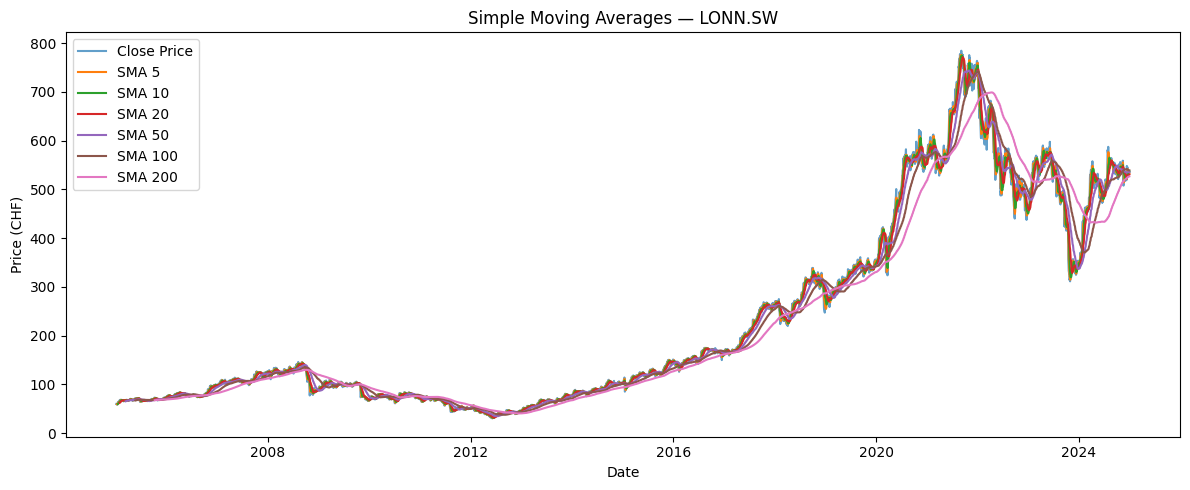

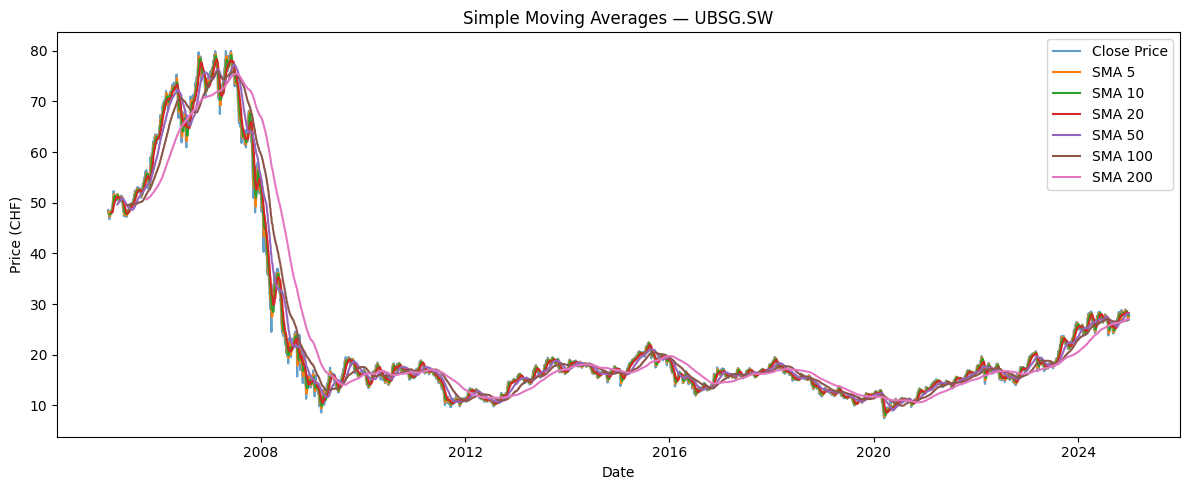

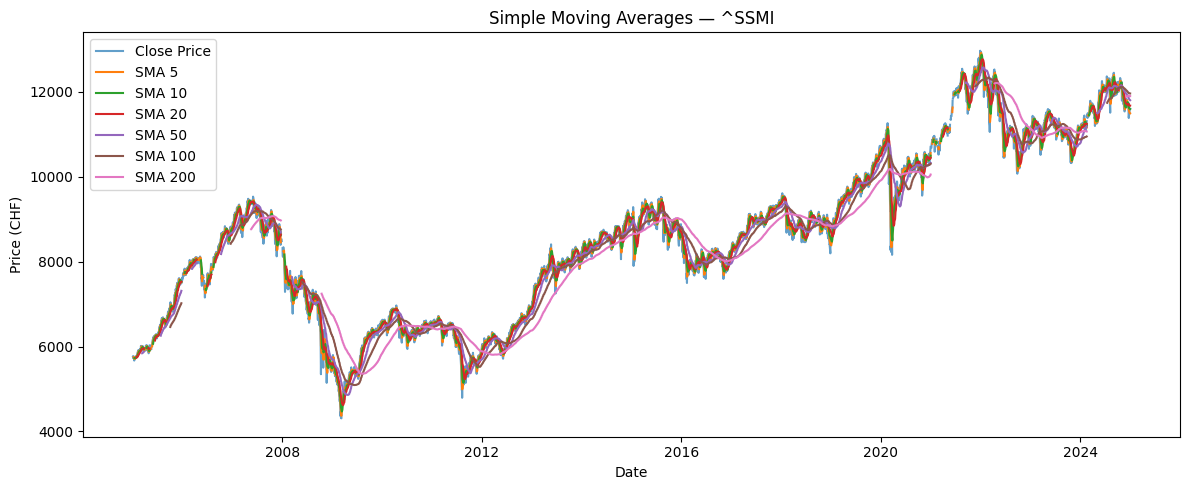

In [20]:
windows = [5, 10, 20, 50, 100, 200]

for col in close.columns:
    plt.figure(figsize=(12, 5))
    plt.plot(close[col], label='Close Price', alpha=0.7)
    
    for w in windows:
        sma = close[col].rolling(window=w).mean()
        plt.plot(sma, label=f'SMA {w}')
    
    plt.title(f'Simple Moving Averages — {col}')
    plt.xlabel('Date')
    plt.ylabel('Price (CHF)')
    plt.legend()
    plt.tight_layout()
    plt.show()


EWMA: With λ = 2/(w+1), it gives more weight to recent prices.

Trading strategies:

- momentum startegy: buy when price is above MA, sell when below - betting the trend continues.
- contrarian strategy: buy when price below MA, sell when above - betting on mean reversion.

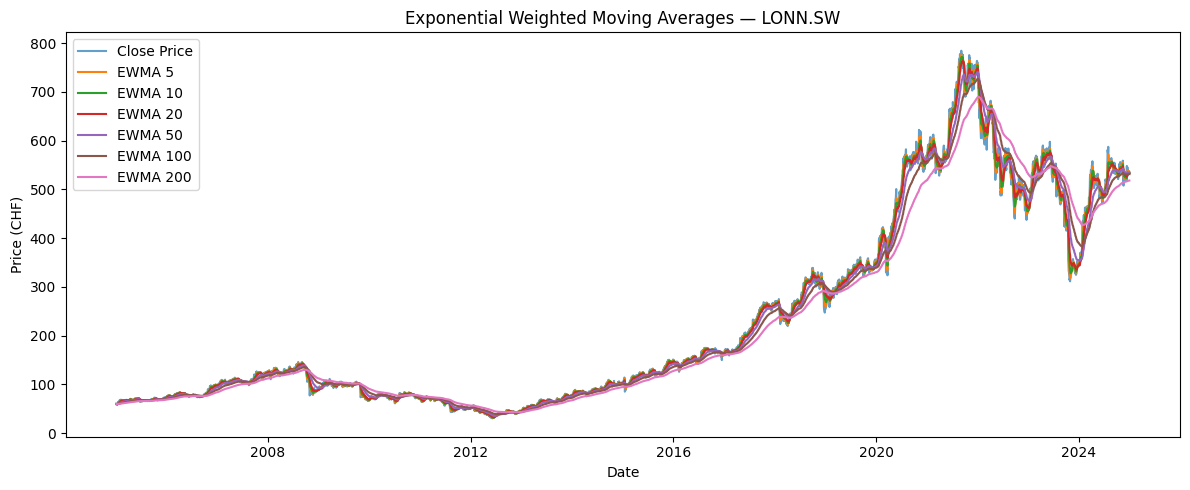

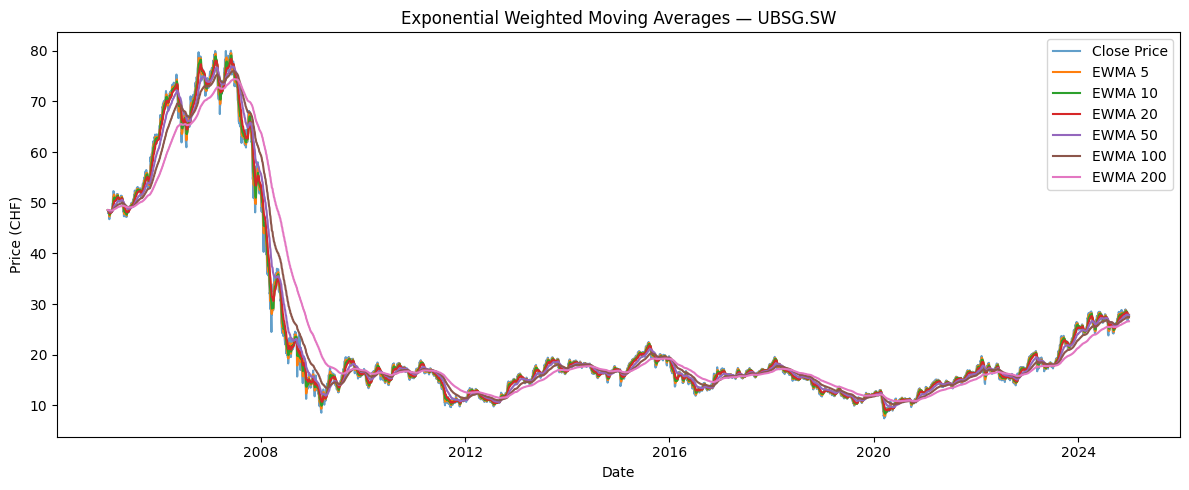

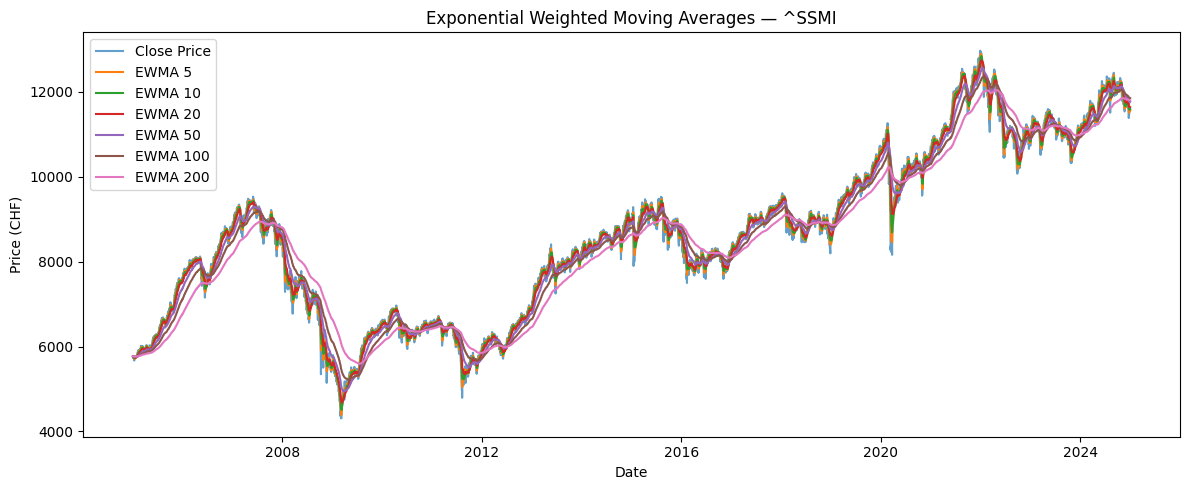

In [21]:
# EWMA for each window
windows = [5, 10, 20, 50, 100, 200]

for col in close.columns:
    plt.figure(figsize=(12, 5))
    plt.plot(close[col], label='Close Price', alpha=0.7)
    
    for w in windows:
        ewma = close[col].ewm(span=w, adjust=False).mean()
        plt.plot(ewma, label=f'EWMA {w}')
    
    plt.title(f'Exponential Weighted Moving Averages — {col}')
    plt.xlabel('Date')
    plt.ylabel('Price (CHF)')
    plt.legend()
    plt.tight_layout()
    plt.show()


In [22]:
# Backtest contrarian and momentum strategies
results = []

for col in close.columns:
    for w in windows:
        ewma = close[col].ewm(span=w, adjust=False).mean()
        daily_ret = close[col].pct_change()
        
        # Signal: compare price to EWMA
        # Momentum: buy (1) when price > EWMA, sell (-1) when price < EWMA
        momentum_signal = np.where(close[col] > ewma, 1, -1)
        # Contrarian: opposite
        contrarian_signal = -momentum_signal
        
        # Strategy returns: signal from yesterday applied to today's return
        # Shift signal by 1 to avoid look-ahead bias
        momentum_ret = daily_ret * pd.Series(momentum_signal, index=close[col].index).shift(1)
        contrarian_ret = daily_ret * pd.Series(contrarian_signal, index=close[col].index).shift(1)
        
        results.append({
            'Stock': col,
            'Window': w,
            'Buy & Hold (ann.)': daily_ret.mean() * 252,
            'Momentum (ann.)': momentum_ret.mean() * 252,
            'Contrarian (ann.)': contrarian_ret.mean() * 252,
        })

results_df = pd.DataFrame(results)

for col in close.columns:
    print(f"\n--- {col} ---")
    subset = results_df[results_df['Stock'] == col].set_index('Window')
    print(subset[['Buy & Hold (ann.)', 'Momentum (ann.)', 'Contrarian (ann.)']].to_string())



--- LONN.SW ---
        Buy & Hold (ann.)  Momentum (ann.)  Contrarian (ann.)
Window                                                       
5                0.153255        -0.018021           0.018021
10               0.153255         0.026989          -0.026989
20               0.153255         0.029486          -0.029486
50               0.153255         0.043455          -0.043455
100              0.153255         0.016131          -0.016131
200              0.153255         0.086501          -0.086501

--- UBSG.SW ---
        Buy & Hold (ann.)  Momentum (ann.)  Contrarian (ann.)
Window                                                       
5                0.037027         0.145988          -0.145988
10               0.037027         0.141850          -0.141850
20               0.037027         0.054926          -0.054926
50               0.037027        -0.018492           0.018492
100              0.037027         0.046647          -0.046647
200              0.037027        -0.

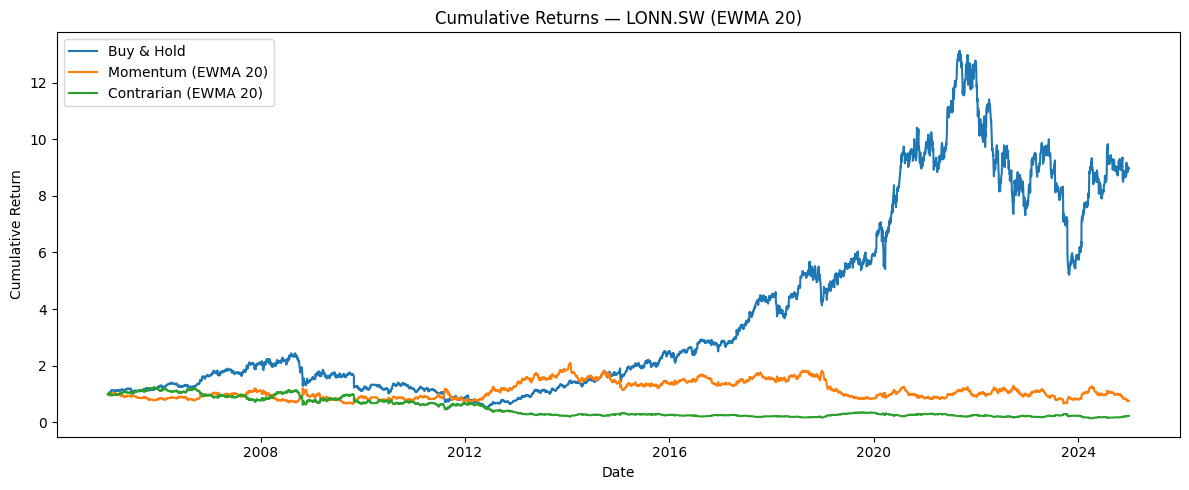

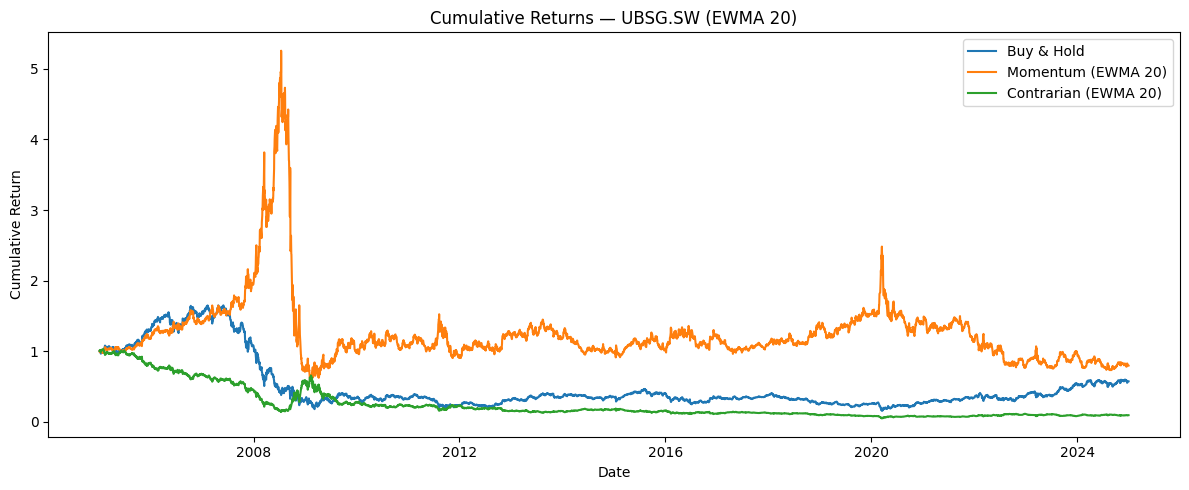

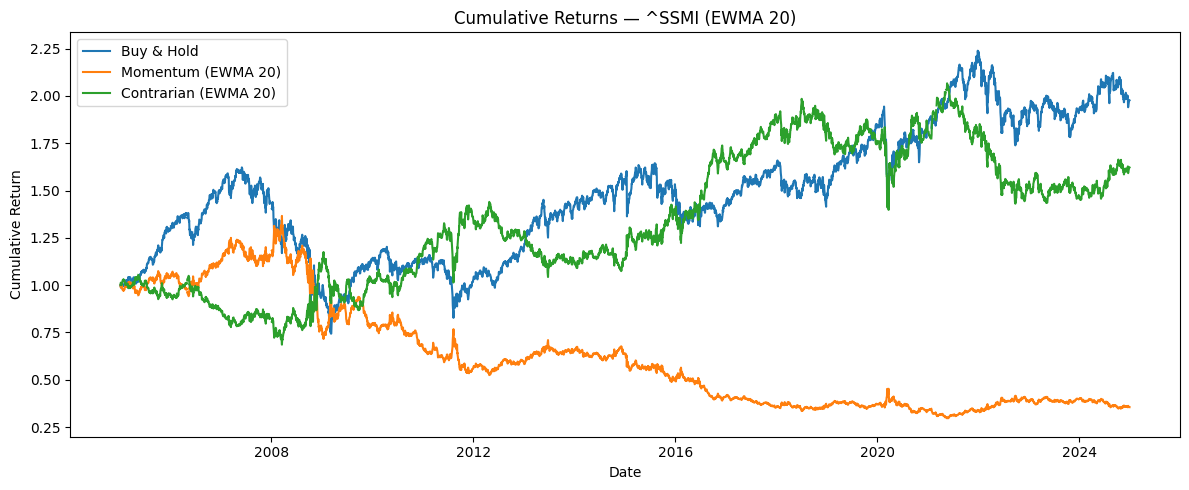

In [ ]:
# Cumulative returns plot for a chosen window (e.g. 20-day)
w = 20

for col in close.columns:
    ewma = close[col].ewm(span=w, adjust=False).mean() # span sets lamba equal to 2/(20+1)
    # .mean() so that it computes the weighted average, ewm(span=w) sets up the exponential weighting scheme.
    daily_ret = close[col].pct_change()
    
    # generate trading signals
    momentum_signal = np.where(close[col] > ewma, 1, -1) # Momentum: buy (1) when price > EWMA, sell (-1) when price < EWMA
    contrarian_signal = -momentum_signal
    
    # shift(1) shift the signal by one day so that we are using yesterday's signal to trade today.
    # avoids look-ahead bias (can't act on information you don't have yet)

    momentum_ret = daily_ret * pd.Series(momentum_signal, index=close[col].index).shift(1)
    contrarian_ret = daily_ret * pd.Series(contrarian_signal, index=close[col].index).shift(1)
    
    # compute cumulative returns
    # buy-and)hold wealth process

    cum_bh = (1 + daily_ret).cumprod()
    cum_mom = (1 + momentum_ret).cumprod()
    cum_con = (1 + contrarian_ret).cumprod()
    
    plt.figure(figsize=(12, 5))
    plt.plot(cum_bh, label='Buy & Hold')
    plt.plot(cum_mom, label=f'Momentum (EWMA {w})')
    plt.plot(cum_con, label=f'Contrarian (EWMA {w})')
    plt.title(f'Cumulative Returns — {col} (EWMA {w})')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Return')
    plt.legend()
    plt.tight_layout()
    plt.show()


Lonza exhibits long-term upward trend and the 20 day momentum rul misses it. Buy & Hold explodes over time.

UBS, buy & hold performs poorly, momentum performs well. UBS is cyclical and volatile, therefore the momentum strategy avoid large crashes.

The 20-day EWMA rule is a very short-term signal and it works well in crisis/trending market, but fails in smooth long-term growth stocks and fail in low-volatility mean-reverting indices.

## Exercice 3